Q1) What are Type I and Type II errors in hypothesis testing, and how do they impact decision-making?

Ans:  In hypothesis testing, we test two statements:

*	Null Hypothesis (H₀): No effect/no difference (default assumption)
*	Alternative Hypothesis (H₁): There is an effect/difference

When making a decision, we may make two types of errors:

1.	Type I Error (False Positive)

*	Rejecting the null hypothesis when it is actually true.
Probability of Type I Error:
*	Denoted by α (alpha)
*	Common value: 0.05
Impact on decision-making:

*	You may wrongly implement a treatment, policy, or change based on a false claim.
*	More serious in situations where false positives are dangerous (e.g., approving a bad drug).

2.	Type II Error (False Negative)

*	Failing to reject the null hypothesis when it is actually false.
Probability of Type II Error:

*	Denoted by β (beta)

Impact on decision-making:

*	You miss a real effect or real opportunity.
*	More serious in situations like diagnosing a disease (missing a real illness).


Q2) What is the P-value in hypothesis testing, and how should it be interpreted in the context of the null hypothesis?

Ans: The p-value is the probability of getting the observed result (or something more extreme) assuming that the null hypothesis (H₀) is true.

If small p-value means:

*	The observed data is very unlikely under the null hypothesis
*	There is evidence against H₀
*	Results are statistically significant

If large p-value means:

*	The data is likely under the null hypothesis
*	There is insufficient evidence against H₀
*	You cannot conclude any significant effect


Q3) Explain the difference between a Z-test and a T-test, including when to use each?

Ans:

1.	Z-test
*  Sample size is large (n ≥ 30)
*  Population standard deviation (σ) is known
*  Data is approximately normally distributed

2.	T-test
* Sample size is small (n < 30)
*  Population standard deviation (σ) is NOT known
*  Data is normally distributed (or close to normal)


Q4) What is a confidence interval, and how does the margin of error influence its width and interpretation?

Ans: A confidence interval (CI) is a range of values that is likely to contain the true population parameter (like the mean or proportion) with a certain level of confidence (usually 95%).

The margin of error (ME) is the amount added and subtracted from the sample estimate to form the confidence interval.

Formula:   "CI"="sample estimate"±"margin of error"

Larger Margin of Error → Wider Interval

 * More uncertainty
* Less precise estimate

	Example:
50 ± 5 → (45, 55) → wide CI


Q5) Describe the purpose and assumptions of an ANOVA test. How does it extend hypothesis testing to more than two groups?

Ans: ANOVA (Analysis of Variance) is used to determine whether three or more group means are significantly different from each other.

* A t-test can compare only two means.
* But when you have 3, 4, or more groups, doing multiple t-tests increases the Type I error (false positives).

ANOVA solves this by testing all group means simultaneously with one test.

It checks:     

```
# H_0:μ_1=μ_2=μ_3=⋯
  H_1:"At least one " μ" is different
```


If ANOVA is significant, you can then use post-hoc tests (Tukey, Bonferroni) to find which groups differ.

ANOVA has three main assumptions:
* Independence of observations
* Normality
* Homogeneity of variances (Equal variances)


In [ ]:
# Q6) Write a Python program to perform a one-sample Z-test and interpret the result for a given dataset?

import numpy as np
from math import sqrt
from scipy.stats import norm


data = [52, 55, 49, 50, 53, 54, 48, 51, 56, 50]   # sample values
population_mean = 50                             # H0: μ = 50
population_std = 5                               # known population standard deviation
alpha = 0.05                                     # significance level


sample_mean = np.mean(data)
sample_size = len(data)


se = population_std / sqrt(sample_size)


z_stat = (sample_mean - population_mean) / se


p_value = 2 * (1 - norm.cdf(abs(z_stat)))


print("Sample Mean:", sample_mean)
print("Z-statistic:", z_stat)
print("P-value:", p_value)


if p_value < alpha:
    print("Reject the null hypothesis: Sample mean is significantly different from population mean.")
else:
    print("Fail to reject the null hypothesis: No significant difference between sample and population mean.")


Sample Mean: 51.8
Z-statistic: 1.1384199576606149
P-value: 0.2549451643173217
Fail to reject the null hypothesis: No significant difference between sample and population mean.


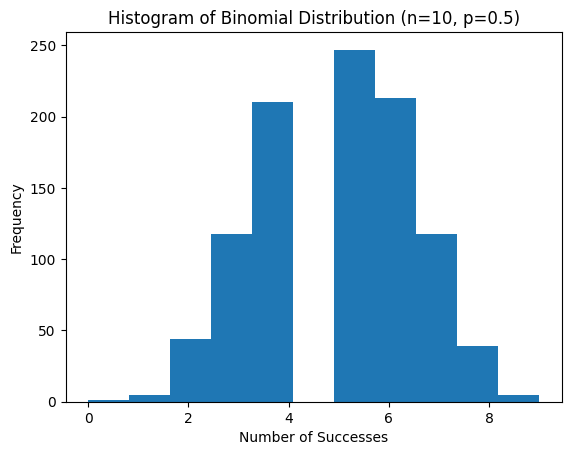

In [ ]:
# Q7) Simulate a dataset from a binomial distribution (n = 10, p = 0.5) using NumPy and plot the histogram.

import numpy as np
import matplotlib.pyplot as mt


n = 10
p = 0.5
size = 1000


data = np.random.binomial(n, p, size)

mt.hist(data, bins=11)
mt.xlabel("Number of Successes")
mt.ylabel("Frequency")
mt.title("Histogram of Binomial Distribution (n=10, p=0.5)")
mt.show()


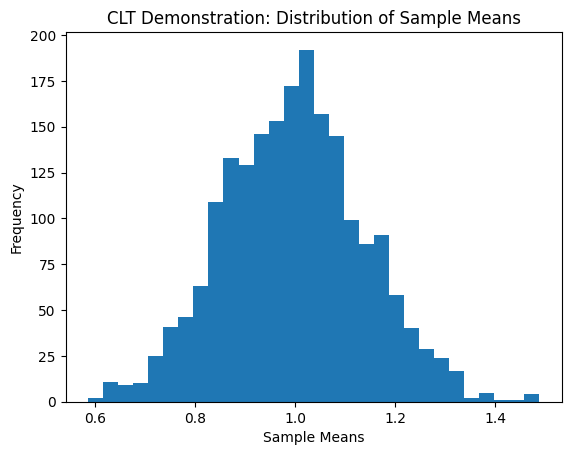

In [ ]:
# Q8) Generate multiple samples from a non-normal distribution and implement the Central Limit Theorem using Python.

import numpy as np
import matplotlib.pyplot as mt

population = np.random.exponential(scale=1, size=100000)

sample_size = 50
num_samples = 2000

sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

mt.hist(sample_means, bins=30)
mt.xlabel("Sample Means")
mt.ylabel("Frequency")
mt.title("CLT Demonstration: Distribution of Sample Means")
mt.show()



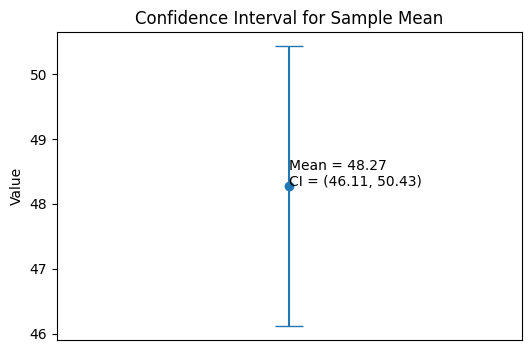

In [ ]:
# Q9) Write a Python function to calculate and visualize the confidence interval for a sample mean.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_confidence_interval(data, confidence=0.95):
    data = np.array(data)

    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)

    se = std / np.sqrt(n)

    z = norm.ppf((1 + confidence) / 2)

    margin_error = z * se

    lower = mean - margin_error
    upper = mean + margin_error

    plt.figure(figsize=(6,4))
    plt.errorbar(1, mean, yerr=margin_error, fmt='o', capsize=10)
    plt.xticks([])
    plt.ylabel("Value")
    plt.title("Confidence Interval for Sample Mean")
    plt.text(1, mean, f"Mean = {mean:.2f}\nCI = ({lower:.2f}, {upper:.2f})")
    plt.show()

sample_data = np.random.normal(loc=50, scale=10, size=100)
plot_confidence_interval(sample_data)



In [ ]:
# Q10) Perform a Chi-square goodness-of-fit test using Python to compare observed and expected distributions, and explain the outcome.

import numpy as np
from scipy.stats import chisquare

# Observed frequencies (from data)
observed = np.array([25, 30, 20, 25])

# Expected frequencies (theoretical or assumed)
expected = np.array([25, 25, 25, 25])

# Perform Chi-square goodness-of-fit test
chi_stat, p_value = chisquare(observed, f_exp=expected)

print("Chi-square Statistic:", chi_stat)
print("P-value:", p_value)


Chi-square Statistic: 2.0
P-value: 0.5724067044708798


* From the Python execution:

Chi-square statistic = 2.00

p-value = 0.5724

We compared:

* Observed distribution: [25, 30, 20, 25]

* Expected distribution (equal frequencies): [25, 25, 25, 25]

 Interpretation

The p-value = 0.57 is greater than 0.05.

This means we fail to reject the null hypothesis.

* Conclusion

There is no significant difference between the observed frequencies and the expected (theoretical) frequencies.